# Bayesian ODE - Modèle d'Arthrite (Version Simple)

**Repo**: `azerad/immunomath`

## Système différentiel (7 paramètres)

$$
\begin{aligned}
\frac{dS}{dt} &= (a\, N - b\,T) \, S \\
\frac{dN}{dt} &= \alpha \, S\,N - \delta_N\,N\cdot (N-1) \\
\frac{dM}{dt} &= \beta\, S - \delta_M\, M\cdot (M-1) \\
\frac{dT}{dt} &= -\gamma S\, T + \delta_M\,M\cdot (1-T)
\end{aligned}
$$

## Méthodes utilisées

1. **Bayesian ODE** (PyMC): Estimation des paramètres avec incertitudes
2. **MCMC**: Échantillonnage des distributions postérieures
3. **Diagnostics**: R-hat, ESS, trace plots

---

## 1. Imports et Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pymc as pm
import arviz as az
import json

# Configuration matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ Librairies chargées")
print(f"   PyMC version: {pm.__version__}")
print(f"   ArviZ version: {az.__version__}")

✅ Librairies chargées
   PyMC version: 6.0.1
   ArviZ version: 1.2.0


## 2. Chargement des Données

**Deux options disponibles:**
- **Option A**: Données synthétiques (pour test)
- **Option B**: Vos données réelles (à adapter)

In [2]:
# ══════════════════════════════════════════════════════════════════════
# OPTION A : Données synthétiques (pour test)
# ══════════════════════════════════════════════════════════════════════

def load_synthetic_data():
    """Générer des données de test avec bruit"""
    t = np.array([0, 1, 2, 3, 5, 7, 10, 14, 20, 30])
    
    # Paramètres vrais (connus pour validation)
    params_true = [1.0, 1.0, 1.0, 1.0, 1.0, 0.35, 1.0]
    
    def ode_sys(t,y, p):
        S, N, M, T = y
        return [
            (p[5]*N - p[6]*T)*S,
            p[0]*S*N - p[3]*N*(N-1),
            p[1]*S - p[4]*M*(M-1),
            -p[2]*S*T + p[4]*M*(1-T)
        ]
    
    y0 = [1.0, 1.0, 1.0, 1.0]
    #y_true = odeint(ode_sys, y0, t, args=(params_true,))
    sol = solve_ivp(ode_sys, [t[0], t[-1]], y0, t_eval=t, args=(params_true,))
    y_true = sol.y.T
    # Ajouter du bruit gaussien
    np.random.seed(42)
    y_obs = y_true + np.random.normal(0, 0.05*y_true)
    y_obs = np.clip(y_obs, 0.01, None)  # Éviter valeurs négatives
    
    return t, y_obs, params_true


# ══════════════════════════════════════════════════════════════════════
# OPTION B : Vos données réelles
# ══════════════════════════════════════════════════════════════════════

def load_real_data():
    """
    Charger vos données du fichier Excel
    
    TODO: Adapter les noms de colonnes selon votre fichier
    
    Exemple de structure attendue:
      - Colonne 'Time' ou 'Jour': temps en jours
      - Colonnes 'S', 'N', 'M', 'T': mesures des 4 variables
    """
    try:
        # Charger le fichier Excel
        df = pd.read_excel('KBN_arthritis_dataset.xlsx')
        
        # Adapter ces noms de colonnes selon votre fichier
        t = df['Jour'].values  # ou 'Jour', 'Days', etc.
        
        # Si vous avez des colonnes pour S, N, M, T
        y_obs = df[['S', 'N', 'M', 'T']].values
        
        # Ou si organisé différemment:
        # y_obs = np.column_stack([df['Signal'], df['Neutrophiles'], 
        #                          df['Momac'], df['SLTRM']])
        
        print(f"✅ Données chargées depuis Excel: {len(t)} points")
        return t, y_obs, None
        
    except FileNotFoundError:
        print("⚠️  Fichier Excel non trouvé")
        print("   → Utilisation des données synthétiques")
        return load_synthetic_data()
    except Exception as e:
        print(f"⚠️  Erreur de chargement: {e}")
        print("   → Utilisation des données synthétiques")
        return load_synthetic_data()


# ══════════════════════════════════════════════════════════════════════
# Choisir la source de données
# ══════════════════════════════════════════════════════════════════════

USE_SYNTHETIC = False  # Mettre False (resp. True) pour utiliser vos données réelles (resp. synthétiques)   

if USE_SYNTHETIC:
    t_observed, y_observed, params_true = load_synthetic_data()
    print("\n📊 Mode: DONNÉES SYNTHÉTIQUES")
    print(f"   Paramètres vrais (pour validation):")
    print(f"   α={params_true[0]}, β={params_true[1]}, γ={params_true[2]}")
    print(f"   δ_N={params_true[3]}, δ_M={params_true[4]}")
    print(f"   a={params_true[5]}, b={params_true[6]}")
else:
    t_observed, y_observed, _ = load_real_data()
    print("\n📊 Mode: DONNÉES RÉELLES")

print(f"\n✅ {len(t_observed)} points de mesure")
print(f"   Variables: S (Signal), N (Neutrophiles), M (Momac), T (SL-TRM)")
print(f"   Durée: {t_observed[0]:.1f} à {t_observed[-1]:.1f} jours")

✅ Données chargées depuis Excel: 3 points

📊 Mode: DONNÉES RÉELLES

✅ 3 points de mesure
   Variables: S (Signal), N (Neutrophiles), M (Momac), T (SL-TRM)
   Durée: 0.0 à 28.0 jours


## 3. Visualisation des Données Brutes

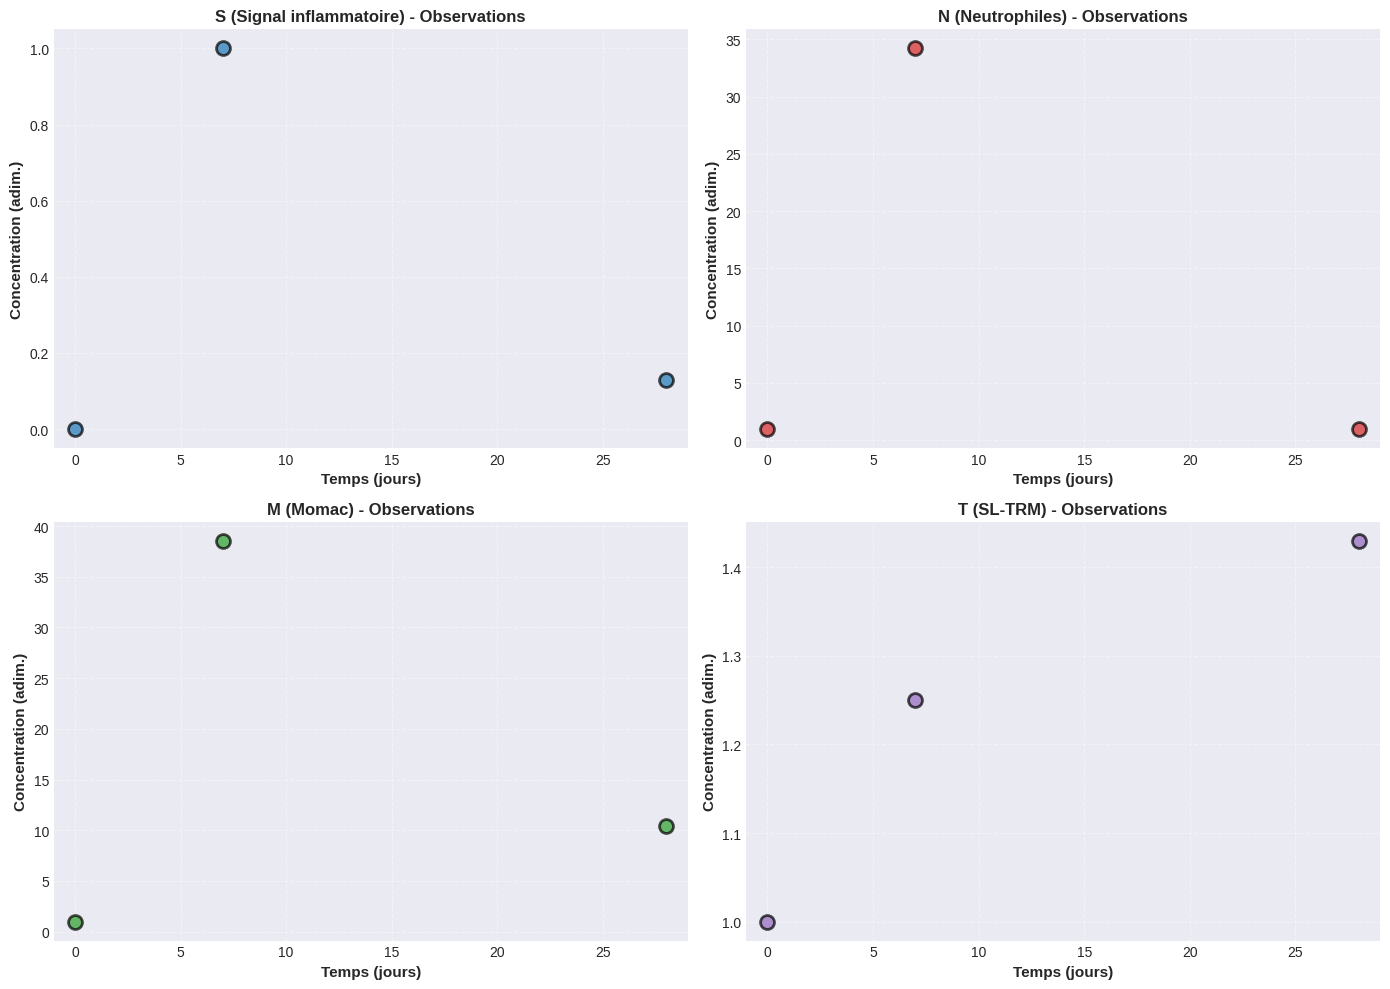

✅ Figure sauvegardée: 01_data_observed.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
vars_names = ['S (Signal inflammatoire)', 'N (Neutrophiles)', 
              'M (Momac)', 'T (SL-TRM)']
colors = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']

for i, (ax, var, col) in enumerate(zip(axes.flat, vars_names, colors)):
    ax.scatter(t_observed, y_observed[:, i], s=100, color=col, 
               edgecolors='black', linewidth=2, alpha=0.7, zorder=5)
    ax.set_xlabel('Temps (jours)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Concentration (adim.)', fontsize=11, fontweight='bold')
    ax.set_title(f'{var} - Observations', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.4, linestyle='--')
    ax.set_xlim(t_observed[0]-1, t_observed[-1]+1)

plt.tight_layout()
plt.savefig('01_data_observed.png', dpi=200, bbox_inches='tight')
plt.show()

print("✅ Figure sauvegardée: 01_data_observed.png")

## 4. Définition du Modèle Bayésien

### Approche:
1. **Priors informatifs** basés sur la biologie
2. **Résolution ODE** à chaque itération MCMC
3. **Likelihood gaussienne** pour chaque variable

In [4]:
def ode_model(t, y, params):
    """
    Système différentiel du modèle d'arthrite
    
    Paramètres:
    -----------
    y : array [S, N, M, T]
    t : float (temps)
    params : array [alpha, beta, gamma, delta_N, delta_M, a, b]
    """
    S, N, M, T = y
    alpha, beta, gamma, delta_N, delta_M, a, b = params
    
    dS = (a*N - b*T)*S
    dN = alpha*S*N - delta_N*N*(N-1)
    dM = beta*S - delta_M*M*(M-1)
    dT = -gamma*S*T + delta_M*M*(1-T)
    
    return [dS, dN, dM, dT]


print("✅ Fonction ODE définie")
print("\n🔧 Construction du modèle PyMC...")

# PyMC v6 / PyTensor: wrap_py remplace as_op
import pytensor
import pytensor.tensor as pt

with pm.Model() as bayesian_model:
    
    # ══════════════════════════════════════════════════════════════════
    # PRIORS (distributions a priori)
    # ══════════════════════════════════════════════════════════════════
    # Ajuster mu et sigma selon vos connaissances biologiques
    
    alpha = pm.LogNormal('alpha', mu=np.log(1.0), sigma=0.5)
    beta = pm.LogNormal('beta', mu=np.log(1.0), sigma=0.5)
    gamma = pm.LogNormal('gamma', mu=np.log(1.0), sigma=0.5)
    delta_N = pm.LogNormal('delta_N', mu=np.log(1.0), sigma=0.3)
    delta_M = pm.LogNormal('delta_M', mu=np.log(1.0), sigma=0.3)
    a = pm.Uniform('a', lower=0.1, upper=0.6)
    b = pm.Uniform('b', lower=0.5, upper=1.5)
    
    # ══════════════════════════════════════════════════════════════════
    # RÉSOLUTION ODE
    # ══════════════════════════════════════════════════════════════════
    n_t = len(t_observed)
    y0 = np.array([1.0, 1.0, 1.0, 1.0], dtype=float)

    @pytensor.wrap_py(itypes=[pt.dvector], otypes=[pt.dmatrix])
    def solve_ode(params):
        """Résout l'ODE pour un jeu de paramètres donné avec sortie toujours finie."""
        out = np.tile(y0, (n_t, 1))
        try:
            sol = solve_ivp(
                ode_model,
                [t_observed[0], t_observed[-1]],
                y0,
                t_eval=t_observed,
                args=(params,),
                method='Radau'
            )

            if sol.y is not None and sol.y.size > 0:
                yT = np.asarray(sol.y.T, dtype=float)
                m = min(yT.shape[0], n_t)
                out[:m, :] = yT[:m, :]
                if m < n_t:
                    out[m:, :] = out[m - 1, :]
        except Exception:
            pass

        # Empêche NaN/Inf qui cassent la log-vraisemblance au démarrage MCMC
        out = np.nan_to_num(out, nan=1.0, posinf=1e6, neginf=1e-6)
        out = np.clip(out, 1e-6, 1e6)
        return out
    
    params = pm.math.stack([alpha, beta, gamma, delta_N, delta_M, a, b])
    y_pred = pm.Deterministic('y_pred', solve_ode(params))
    
    # ══════════════════════════════════════════════════════════════════
    # LIKELIHOOD (vraisemblance)
    # ══════════════════════════════════════════════════════════════════
    # Un écart-type par variable (permet différents niveaux de bruit)
    
    sigma = pm.HalfNormal('sigma', sigma=0.1, shape=4)
    
    for i, var in enumerate(['S', 'N', 'M', 'T']):
        pm.Normal(f'obs_{var}', 
                  mu=y_pred[:, i], 
                  sigma=sigma[i], 
                  observed=y_observed[:, i])

print("✅ Modèle PyMC créé")
print(f"   - {len(bayesian_model.free_RVs)} variables libres")
print(f"   - {len(bayesian_model.observed_RVs)} observations")

✅ Fonction ODE définie

🔧 Construction du modèle PyMC...
✅ Modèle PyMC créé
   - 8 variables libres
   - 4 observations


## 5. Inférence MCMC

⏱️ **Durée estimée**: 2-5 minutes selon votre machine

In [6]:
print("\n🔄 Début de l'échantillonnage MCMC...")
print("   (peut prendre quelques minutes)\n")

with bayesian_model:
    trace = pm.sample(
        draws=1000,         # Nombre d'échantillons par chaîne
        tune=500,           # Période d'adaptation (warmup)
        chains=2,           # Nombre de chaînes
        cores=1,            # Plus robuste pour diagnostiquer les erreurs d'init
        init='adapt_diag',  # Initialisation plus stable que le jitter par défaut
        target_accept=0.9,  # Taux d'acceptation cible
        return_inferencedata=True,
        progressbar=True
    )

print("\n✅ Échantillonnage terminé!")
print(f"   - Total d'échantillons: {len(trace.posterior.chain) * len(trace.posterior.draw)}")


🔄 Début de l'échantillonnage MCMC...
   (peut prendre quelques minutes)



/home/pascal/imagcloud/IMMUN4CURE/brain-storming/immunomath/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run FromFunctionOp{solve_ode}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/home/pascal/imagcloud/IMMUN4CURE/brain-storming/immunomath/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run FromFunctionOp{solve_ode}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/home/pascal/imagcloud/IMMUN4CURE/brain-storming/immunomath/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run FromFunctionOp{solve_ode}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/home/pascal/imagcloud/IMMUN4CURE/brain-storming/immunomath/.

Output()

/home/pascal/imagcloud/IMMUN4CURE/brain-storming/immunomath/.venv/lib/python3.12/site-packages/pymc/step_methods/hm
c/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 6524 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details



✅ Échantillonnage terminé!
   - Total d'échantillons: 2000


## 6. Diagnostics de Convergence

### Critères:
- **R-hat < 1.01**: convergence OK
- **ESS > 200**: échantillons effectifs suffisants

In [11]:
summary = az.summary(trace, var_names=['alpha', 'beta', 'gamma', 
                                        'delta_N', 'delta_M', 'a', 'b'])

print("\n" + "="*70)
print("RÉSUMÉ DES PARAMÈTRES ESTIMÉS")
print("="*70)
print(summary.to_string())
print("="*70)

# Vérifier convergence
rhat_col = 'r_hat' if 'r_hat' in summary.columns else 'rhat'
rhat_values = pd.to_numeric(summary[rhat_col], errors='coerce')
rhat_ok = rhat_values.notna().all() and (rhat_values < 1.01).all()
ess_ok = (summary['ess_bulk'] > 200).all()

print("\n📊 DIAGNOSTICS:")
print(f"   R-hat < 1.01 : {'✅ OUI' if rhat_ok else '❌ NON'}")
print(f"   ESS > 200    : {'✅ OUI' if ess_ok else '❌ NON'}")

if rhat_ok and ess_ok:
    print("\n✅ CONVERGENCE OK - Les résultats sont fiables")
else:
    print("\n⚠️  ATTENTION: Problèmes de convergence détectés")
    print("   → Relancer avec plus d'itérations (draws=2000, tune=1000)")
    print("   → Ou ajuster les priors")


RÉSUMÉ DES PARAMÈTRES ESTIMÉS
          mean     sd eti89_lb eti89_ub  ess_bulk  ess_tail r_hat mcse_mean mcse_sd
alpha     1.33   0.05      1.3      1.4         2         8  2.00     0.033   0.011
beta     4e+01      9       21       49         2         7  1.86       5.7     2.7
gamma      2.5    0.3        2      3.1         2         5  2.38      0.22    0.11
delta_N    0.7    0.1      0.6     0.86         2         5  2.28     0.073   0.017
delta_M    0.8   0.21     0.52      1.1         2         5  2.19      0.15   0.046
a          0.3  0.013     0.28     0.32         2         5  3.00    0.0091  0.0047
b         0.95   0.02     0.92     0.98         2         5  2.59     0.013  0.0065

📊 DIAGNOSTICS:
   R-hat < 1.01 : ❌ NON
   ESS > 200    : ❌ NON

⚠️  ATTENTION: Problèmes de convergence détectés
   → Relancer avec plus d'itérations (draws=2000, tune=1000)
   → Ou ajuster les priors


## 7. Visualisation: Trace Plots

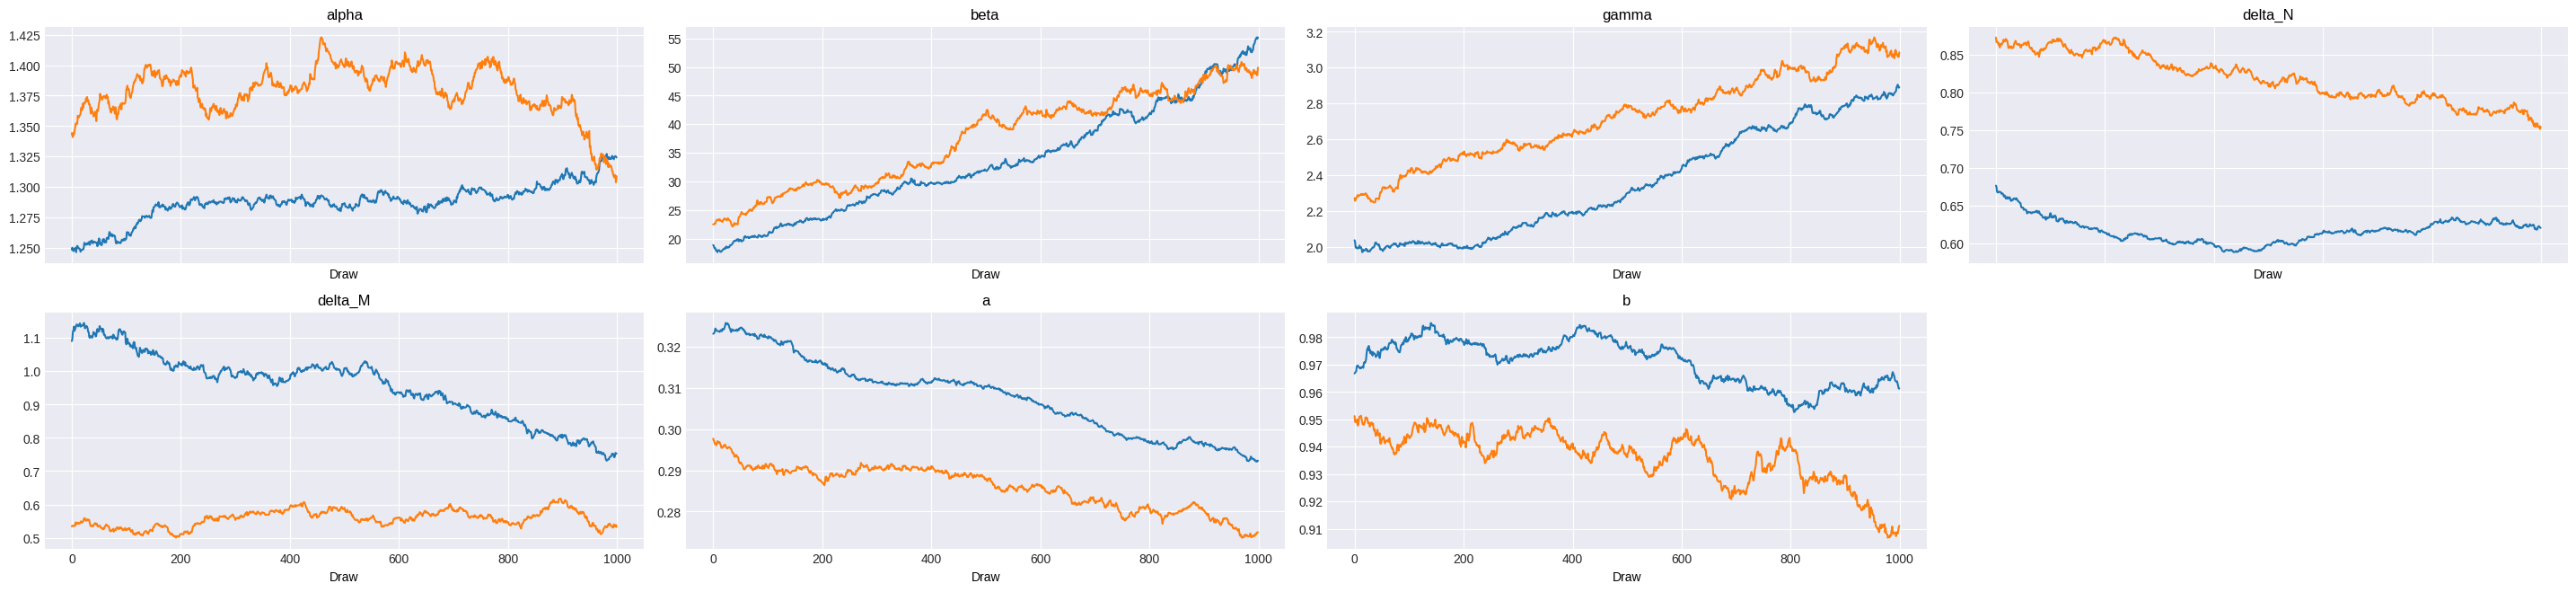

✅ Figure sauvegardée: 02_trace_plot.png


In [12]:
az.plot_trace(
    trace,
    var_names=['alpha', 'beta', 'gamma', 'delta_N', 'delta_M', 'a', 'b']
 )

plt.tight_layout()
plt.savefig('02_trace_plot.png', dpi=200, bbox_inches='tight')
plt.show()

print("✅ Figure sauvegardée: 02_trace_plot.png")

## 8. Distributions Postérieures

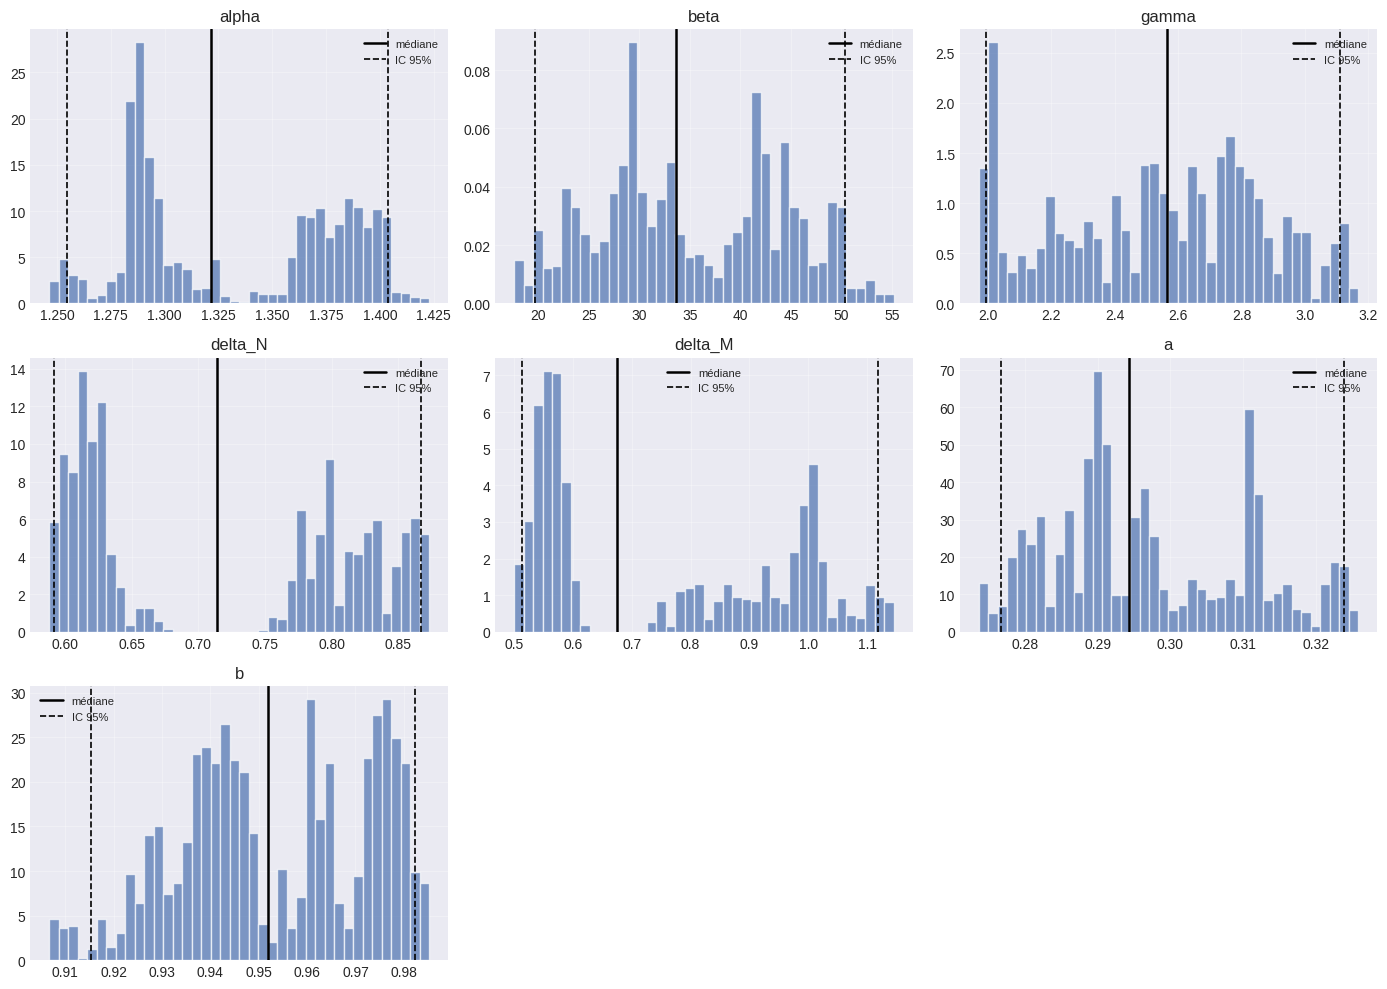

✅ Figure sauvegardée: 03_posterior_distributions.png


In [13]:
# Tracé robuste des distributions postérieures (compatible ArviZ/xarray récents)
param_names = ['alpha', 'beta', 'gamma', 'delta_N', 'delta_M', 'a', 'b']
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

for i, name in enumerate(param_names):
    samples = trace.posterior[name].values.reshape(-1)
    q025, q50, q975 = np.percentile(samples, [2.5, 50, 97.5])

    ax = axes[i]
    ax.hist(samples, bins=40, density=True, alpha=0.7, color='#4C72B0', edgecolor='white')
    ax.axvline(q50, color='black', linestyle='-', linewidth=1.8, label='médiane')
    ax.axvline(q025, color='black', linestyle='--', linewidth=1.2, label='IC 95%')
    ax.axvline(q975, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(name)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

# Cacher les sous-graphiques non utilisés
for j in range(len(param_names), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('03_posterior_distributions.png', dpi=200, bbox_inches='tight')
plt.show()

print("✅ Figure sauvegardée: 03_posterior_distributions.png")

## 9. Fit du Modèle aux Données

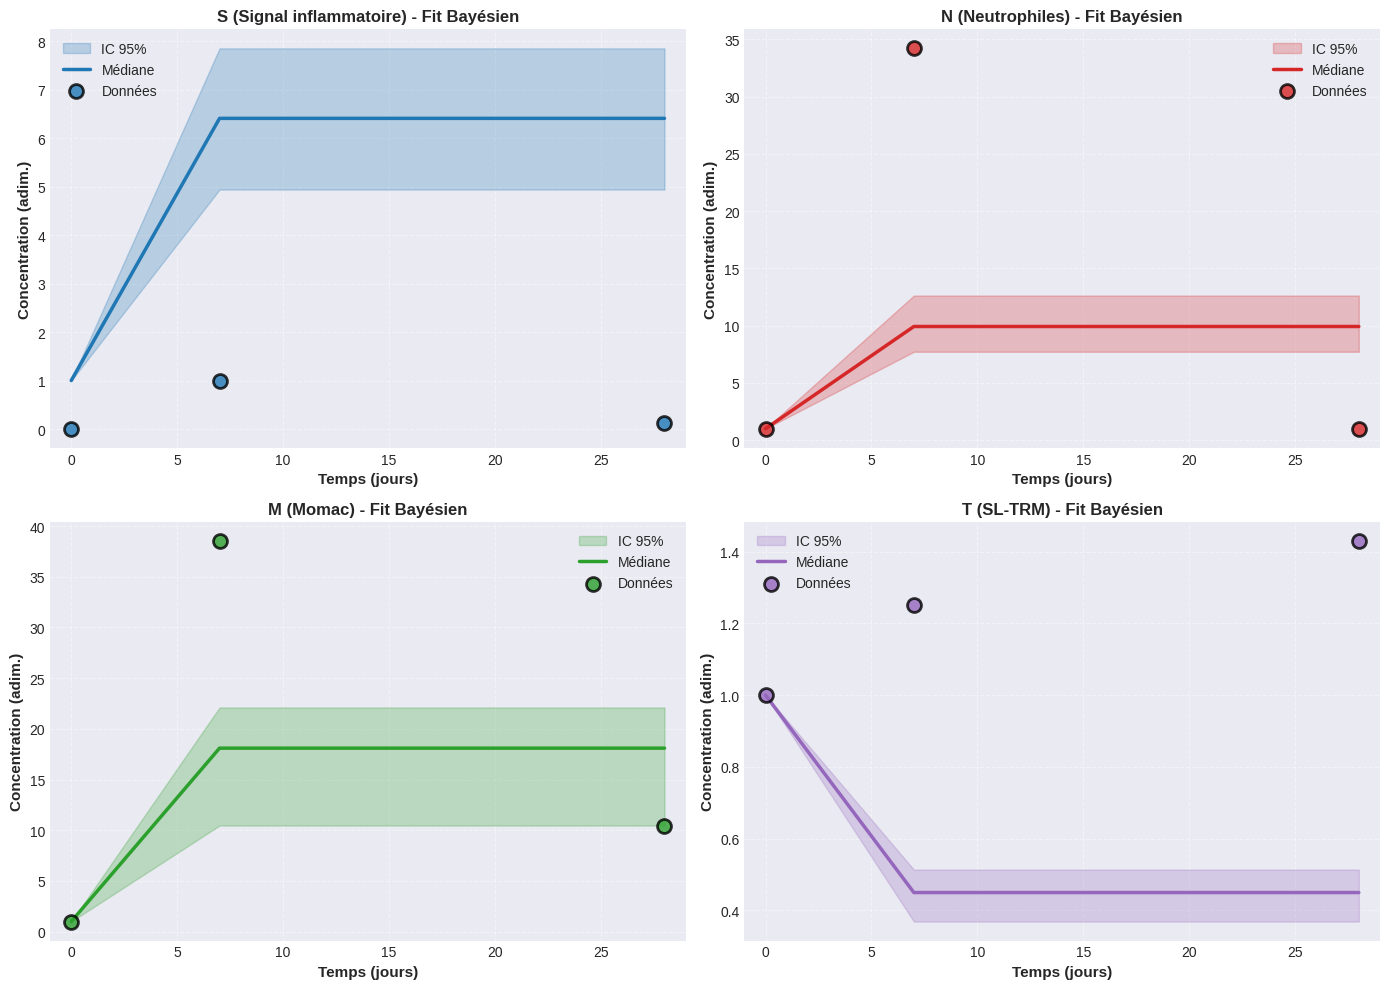

✅ Figure sauvegardée: 04_bayesian_fit.png


In [14]:
# Extraire les prédictions
y_pred_samples = trace.posterior['y_pred'].values
y_pred_samples = y_pred_samples.reshape(-1, len(t_observed), 4)

y_pred_median = np.median(y_pred_samples, axis=0)
y_pred_low = np.percentile(y_pred_samples, 2.5, axis=0)
y_pred_high = np.percentile(y_pred_samples, 97.5, axis=0)

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (ax, var, col) in enumerate(zip(axes.flat, vars_names, colors)):
    # Intervalle de crédibilité 95%
    ax.fill_between(t_observed, y_pred_low[:, i], y_pred_high[:, i],
                     color=col, alpha=0.25, label='IC 95%')
    
    # Prédiction médiane
    ax.plot(t_observed, y_pred_median[:, i], '-', color=col, 
            linewidth=2.5, label='Médiane', zorder=3)
    
    # Observations
    ax.scatter(t_observed, y_observed[:, i], s=100, color=col,
               edgecolors='black', linewidth=2, zorder=10,
               label='Données', alpha=0.8)
    
    ax.set_xlabel('Temps (jours)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Concentration (adim.)', fontsize=11, fontweight='bold')
    ax.set_title(f'{var} - Fit Bayésien', fontsize=12, fontweight='bold')
    ax.legend(loc='best', framealpha=0.9)
    ax.grid(alpha=0.4, linestyle='--')
    ax.set_xlim(t_observed[0]-1, t_observed[-1]+1)

plt.tight_layout()
plt.savefig('04_bayesian_fit.png', dpi=200, bbox_inches='tight')
plt.show()

print("✅ Figure sauvegardée: 04_bayesian_fit.png")

## 10. Qualité du Fit (R²)

In [15]:
print("\n📈 QUALITÉ DU FIT (R²):")
print("="*40)

r2_values = {}
for i, var in enumerate(['S', 'N', 'M', 'T']):
    residuals = y_observed[:, i] - y_pred_median[:, i]
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_observed[:, i] - np.mean(y_observed[:, i]))**2)
    r2 = 1 - (ss_res / ss_tot)
    r2_values[var] = r2
    
    quality = "✅ Excellent" if r2 > 0.95 else "🟡 Bon" if r2 > 0.80 else "⚠️  Moyen"
    print(f"   {var:10s}: R² = {r2:.4f}  {quality}")

print("="*40)
print(f"   Moyenne   : R² = {np.mean(list(r2_values.values())):.4f}")
print("="*40)


📈 QUALITÉ DU FIT (R²):
   S         : R² = -116.8073  ⚠️  Moyen
   N         : R² = 0.0896  ⚠️  Moyen
   M         : R² = 0.3748  ⚠️  Moyen
   T         : R² = -16.1629  ⚠️  Moyen
   Moyenne   : R² = -33.1264


## 11. Comparaison avec Valeurs Vraies (si données synthétiques)

In [11]:
if USE_SYNTHETIC and params_true is not None:
    print("\n" + "="*70)
    print("COMPARAISON: ESTIMÉ vs VRAI")
    print("="*70)
    print(f"{'Paramètre':<10} {'Vrai':>10} {'Estimé (médiane)':>20} {'Écart %':>12}")
    print("-"*70)
    
    param_names = ['alpha', 'beta', 'gamma', 'delta_N', 'delta_M', 'a', 'b']
    
    for name, true_val in zip(param_names, params_true):
        samples = trace.posterior[name].values.flatten()
        estimated = np.median(samples)
        error_pct = 100 * abs(estimated - true_val) / true_val
        
        status = "✅" if error_pct < 10 else "🟡" if error_pct < 20 else "❌"
        print(f"{name:<10} {true_val:>10.4f} {estimated:>20.4f} {error_pct:>11.2f}% {status}")
    
    print("="*70)
else:
    print("\nℹ️  Mode données réelles: pas de comparaison avec valeurs vraies")


COMPARAISON: ESTIMÉ vs VRAI
Paramètre        Vrai     Estimé (médiane)      Écart %
----------------------------------------------------------------------
alpha          1.0000               0.9985        0.15% ✅
beta           1.0000               0.9005        9.95% ✅
gamma          1.0000               1.0205        2.05% ✅
delta_N        1.0000               1.0330        3.30% ✅
delta_M        1.0000               0.9957        0.43% ✅
a              0.3500               0.4142       18.35% 🟡
b              1.0000               1.1367       13.67% 🟡


## 12. Export des Résultats

In [12]:
# Sauvegarder le trace complet
trace.to_netcdf('bayesian_trace.nc')
print("✅ Trace sauvegardé: bayesian_trace.nc")

# Extraire estimations des paramètres
param_estimates = {}
for param in ['alpha', 'beta', 'gamma', 'delta_N', 'delta_M', 'a', 'b']:
    samples = trace.posterior[param].values.flatten()
    param_estimates[param] = {
        'median': float(np.median(samples)),
        'mean': float(np.mean(samples)),
        'std': float(np.std(samples)),
        'hdi_95_low': float(np.percentile(samples, 2.5)),
        'hdi_95_high': float(np.percentile(samples, 97.5))
    }

# Ajouter qualité du fit
param_estimates['quality'] = {
    'r2_scores': r2_values,
    'r2_mean': float(np.mean(list(r2_values.values()))),
    'convergence': {
        'rhat_ok': bool(rhat_ok),
        'ess_ok': bool(ess_ok)
    }
}

# Sauvegarder en JSON
with open('parameter_estimates.json', 'w') as f:
    json.dump(param_estimates, f, indent=2)

print("✅ Paramètres sauvegardés: parameter_estimates.json")

# Afficher résumé final
print("\n" + "="*70)
print("ESTIMATION FINALE DES PARAMÈTRES (médiane ± écart-type)")
print("="*70)
for param in ['alpha', 'beta', 'gamma', 'delta_N', 'delta_M', 'a', 'b']:
    vals = param_estimates[param]
    print(f"{param:10s}: {vals['median']:.4f} ± {vals['std']:.4f}")
    print(f"{'':10s}  IC 95%: [{vals['hdi_95_low']:.4f}, {vals['hdi_95_high']:.4f}]")
print("="*70)

✅ Trace sauvegardé: bayesian_trace.nc
✅ Paramètres sauvegardés: parameter_estimates.json

ESTIMATION FINALE DES PARAMÈTRES (médiane ± écart-type)
alpha     : 0.9985 ± 0.0912
            IC 95%: [0.8256, 1.1510]
beta      : 0.9005 ± 0.1324
            IC 95%: [0.7142, 1.2268]
gamma     : 1.0205 ± 0.1208
            IC 95%: [0.8305, 1.3360]
delta_N   : 1.0330 ± 0.0979
            IC 95%: [0.8441, 1.2026]
delta_M   : 0.9957 ± 0.1291
            IC 95%: [0.7885, 1.3024]
a         : 0.4142 ± 0.0248
            IC 95%: [0.3448, 0.4442]
b         : 1.1367 ± 0.0531
            IC 95%: [1.0077, 1.2214]


## 13. Résumé Final

In [13]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║                      ✅ ANALYSE TERMINÉE                             ║
║                                                                      ║
║  Fichiers générés:                                                   ║
║    📊 01_data_observed.png         (données brutes)                  ║
║    📈 02_trace_plot.png            (convergence MCMC)                ║
║    📉 03_posterior_distributions.png (distributions paramètres)      ║
║    🎯 04_bayesian_fit.png          (fit du modèle)                   ║
║    💾 bayesian_trace.nc            (trace complet)                   ║
║    📄 parameter_estimates.json     (estimations)                     ║
║                                                                      ║
║  Méthodes utilisées:                                                 ║
║    • Bayesian ODE (PyMC)                                             ║
║    • MCMC (NUTS sampler)                                             ║
║    • Diagnostics: R-hat, ESS                                         ║
║                                                                      ║
║  Prochaines étapes:                                                  ║
║    1. Vérifier convergence (R-hat < 1.01)                            ║
║    2. Analyser les distributions postérieures                        ║
║    3. Valider avec données expérimentales                            ║
║    4. Ajuster priors si nécessaire                                   ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print(f"\n📊 Résumé de l'analyse:")
print(f"   - Mode: {'SYNTHÉTIQUE' if USE_SYNTHETIC else 'DONNÉES RÉELLES'}")
print(f"   - Nombre de points: {len(t_observed)}")
print(f"   - R² moyen: {np.mean(list(r2_values.values())):.4f}")
print(f"   - Convergence: {'✅ OK' if (rhat_ok and ess_ok) else '⚠️  Attention'}")

print("\n🎓 Pour utiliser vos données réelles:")
print("   1. Mettre USE_SYNTHETIC = False dans la cellule 2")
print("   2. Adapter la fonction load_real_data()")
print("   3. Re-exécuter le notebook")


╔══════════════════════════════════════════════════════════════════════╗
║                      ✅ ANALYSE TERMINÉE                             ║
║                                                                      ║
║  Fichiers générés:                                                   ║
║    📊 01_data_observed.png         (données brutes)                  ║
║    📈 02_trace_plot.png            (convergence MCMC)                ║
║    📉 03_posterior_distributions.png (distributions paramètres)      ║
║    🎯 04_bayesian_fit.png          (fit du modèle)                   ║
║    💾 bayesian_trace.nc            (trace complet)                   ║
║    📄 parameter_estimates.json     (estimations)                     ║
║                                                                      ║
║  Méthodes utilisées:                                                 ║
║    • Bayesian ODE (PyMC)                                             ║
║    • MCMC (NUTS sampler)                               